In [3]:
# データを読み込んで形を確認
import pandas as pd

print(pd.read_excel(r"C:\Users\sryoh\Documents\Python_MSSE_analysis\Ex1\89SEDEx1.xls", sheet_name=None))

WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
{'Sheet1':     Time[sec.]     Interval   Interval.1   Interval.2      Interval.3  \
0   Time[sec.]  Nｺ Episodes  Nｺ Episodes  Nｺ Episodes  Time in [sec.]   
1   Time[sec.]       Freez.          Low         High          Freez.   
2           30            3            3            0            24.8   
3           60            4            4            0           29.22   
4           90            0            0            0              30   
5          120            1            1            0           29.98   
6          150            0            0            0              30   
7          180            2            2            0           28.88   
8          210            0            0            0              30   
9          240            0            0            0              30   
10         270            2            2            0           29.92   
11         300            1            1

In [ ]:
# RのコードをPythonに変換 
import pandas as pd


def read_per3_bin(file_path: str, name: str) -> pd.DataFrame: # 3分毎のbinごとにデータを読み込む
    df = pd.read_excel(file_path) # データを読み込む

    bins = [ # 3分毎のbinの範囲とラベル
        (3, 8, "3"),
        (9, 14, "6"),
        (15, 20, "9"),
        (21, 26, "12"),
        (27, 32, "15"),
    ]

    frames = [] # 結果を格納するリスト
    for start, end, time_label in bins: # 3分毎のbinごとにデータを処理
        tmp = (
            df.iloc[:, 4]           # 5列目（0-indexed）
            .iloc[start - 1 : end]  # 行 3:8, 9:14, ...
            .astype(float)          # 数値に変換
            .mul(100 / 30 )         # 30秒ごとのデータを3分ごとの平均に変換
        )

        frames.append( # 結果をリストに追加
            pd.DataFrame({  # データフレームを作成
                "Freezing": [tmp.mean()], # 平均値を計算
                "Time": [time_label], # ラベルを追加
                "No": [name], # 名前を追加
            })
        )

    return pd.concat(frames, ignore_index=True)

# 例:
tmp = read_per3_bin("path/to/file.xls", "animal_name")

In [ ]:
# 3分毎の折れ線グラフ用のFear Extinctionデータの読み込み

from pathlib import Path  # noqa: F811

import numpy as np  # noqa: F811
import pandas as pd

# 自動でエクセルファイルを読み込む

folder_Ex1 = r"C:\Users\sryoh\Documents\Python_MSSE_analysis\Ex1"  # フォルダのパスを指定
folder_Ex2 = r"C:\Users\sryoh\Documents\Python_MSSE_analysis\Ex2"  # フォルダのパスを指定

files_Ex1 = sorted(Path(folder_Ex1).glob("*.xls")) # フォルダ内の .xls ファイルを取得してソート
files_Ex2 = sorted(Path(folder_Ex2).glob("*.xls")) # フォルダ内の .xls ファイルを取得してソート

if not files_Ex1 and not files_Ex2:
    print("指定されたフォルダに .xls ファイルはありません")
else:
    dfs = [] # 空のリストを作成して、各ファイルのデータフレームを格納
    for file in files_Ex1 + files_Ex2: # ファイルごとにループ
        df = (
        pd.read_excel(file) 
        .iloc[2:8, [4]]  # 2行目から7行目まで、4列目を抽出
        .assign(Freezing = lambda df: df['Interval.3'] / 60 * 100 ) # Freezing Time (%) を計算し列に追加
        [['Freezing']] # Freezing列のみを残す
        .assign(
        Time  = lambda df: list(range(1, len(df) + 1)), # Time列に1から行数までの連番を追加
        No = lambda df: Path(file).stem,  # No列にpathからファイル名を抽出して追加
        Group = lambda df: np.select( # Group列に条件に応じた値を追加
            condlist=[ # 条件のリスト：No列に各文字列が含まれているか
                df['No'].str.contains('SED'),
                df['No'].str.contains('LIE'),
                df['No'].str.contains('MOE')
            ],
            choicelist=['SED', 'LIE', 'MOE'], # 条件にマッチしたときに入れる値のリスト
            default='Other' # どれにも当てはまらない場合のデフォルト値
            )
        )
     )
        dfs.append(df) # データフレームをリストに追加

    dataFC = pd.concat(dfs, ignore_index=True) # リスト内のデータフレームを縦に結合して1つのデータフレームにする
    print(f"{len(files_Ex1 + files_Ex2)} 件の .xls ファイルを読み込みました") # 読み込んだファイル数を表示
    print(dataFC) # データフレームの内容を表示

In [3]:
# 上の関数と自動読み込みのコードをハイブリットしたコード

import warnings
from pathlib import Path

import numpy as np
import pandas as pd

# 旧形式 .xls の OLE2 警告を抑制
# warnings.filterwarnings("ignore", message=".*OLE2 inconsistency.*")

def infer_group(name: str) -> str: # ファイル名からグループを推測する関数
    if "SED" in name:
        return "SED"
    elif "LIE" in name:
        return "LIE"
    elif "MOE" in name:
        return "MOE"
    return "Other"

def read_extinction_per3(files):   # 3分ごとのデータを読み込む関数
    rows = [] # 空のリストを作成して、各ファイルのデータを格納

    for file in files:
        # 旧 .xls では pandas で警告が出ることがあるので抑制
        # with warnings.catch_warnings():
            # warnings.filterwarnings("ignore", message=".*OLE2 inconsistency.*")
        df = pd.read_excel(file)

        col5 = pd.to_numeric(df.iloc[:, 4], errors="coerce")  # 5列目（E列）
        bins = [ # 3分毎のbinの範囲とラベル
            (3, 8, "3"),
            (9, 14, "6"),
            (15, 20, "9"),
            (21, 26, "12"),
            (27, 32, "15"),
        ]

        for start, end, time_label in bins: # 3分毎のbinごとにデータを処理
            freezing = (
                col5.iloc[start - 1:end] # 3:8, 9:14, ...
                .astype(float)           # 数値に変換
                .mul(100 / 30)           # 30秒ごとのデータを3分ごとの平均に変換
                .mean()                  # 平均値を計算  
            )
            rows.append({
                "No": Path(file).stem,   # ファイル名を追加
                "Time": time_label,      # ラベルを追加
                "Freezing": freezing,    # 平均値を追加
                "Group": infer_group(Path(file).stem),  # グループを推測して追加
            })

    return pd.DataFrame(rows)

# 既存のフォルダ
folder_Ex1 = r"C:\Users\sryoh\Documents\Python_MSSE_analysis\Ex1"
folder_Ex2 = r"C:\Users\sryoh\Documents\Python_MSSE_analysis\Ex2"

files_Ex1 = sorted(Path(folder_Ex1).glob("*.xls")) # フォルダ内の .xls ファイルを取得してソート
files_Ex2 = sorted(Path(folder_Ex2).glob("*.xls")) # フォルダ内の .xls ファイルを取得してソート

# 3分ごとのデータ
if not files_Ex1 and not files_Ex2:
    print("指定されたフォルダに .xls ファイルはありません")
else:
    dataEx1_per3 = read_extinction_per3(files_Ex1) # Ex1の3分ごとのデータを読み込む
    dataEx2_per3 = read_extinction_per3(files_Ex2) # Ex2の3分ごとのデータを読み込む

    print(f"Ex1: {len(files_Ex1)} 件, Ex2: {len(files_Ex2)} 件") 
    print(dataEx1_per3.head()) 
    print(dataEx2_per3.head())

WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but 

In [4]:
# グラフの描画を関数化

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager
from matplotlib.lines import Line2D

# --- 保存先 ---
save_dir = Path(r"C:\Users\sryoh\Documents\Python_MSSE_analysis\Results\Plots")
save_dir.mkdir(parents=True, exist_ok=True)

# --- フォント ---
plt.rcParams["font.family"] = ["Times New Roman", "DejaVu Serif", "serif"]
plt.rcParams["axes.unicode_minus"] = False
font_prop = font_manager.FontProperties(family="Times New Roman")


def _get_object_name(obj):
    """オブジェクトが格納されている変数名を返す"""
    for scope in (globals(), locals()):
        for name, value in scope.items():
            if value is obj:
                return name
    return "unnamed_df"


def plot_save(
    df,
    *,
    title="Extinction",
    group_col="Group",
    time_col="Time",
    value_col="Freezing",
    group_order=("SED", "LIE", "MOE"),
    palette=None,
    xlabel="Time (min)",
    ylabel="Freezing Time (%)",
    ylim=(0, 100),
    xticks=(3, 6, 9, 12, 15),
    figsize=(3, 3),
    save_path=None,
    show_legend=True,
    legend_loc="upper left",
    legend_title=None,
    legend_frameon=False,
    method="seaborn",
):
    """
    3群の折れ線グラフを作成して、必要なら保存し、グラフ変数を自動で保存する

    Parameters
    ----------
    df : pd.DataFrame
        解析用データ
    show_legend : bool
        凡例を表示するか
    legend_loc : str
        凡例位置: "upper left", "upper right", "lower left", "lower right", "best" など
    legend_title : str | None
        凡例タイトル
    legend_frameon : bool
        凡例の枠を表示するか
    method : {"seaborn", "matplotlib"}
        描画手法
    """

    df_name = _get_object_name(df)
    plot_var_name = f"plot_{df_name}"

    if palette is None:
        palette = {
            "SED": "gray",
            "LIE": "skyblue",
            "MOE": "lightgreen",
        }

    df = df.copy()
    df[time_col] = pd.to_numeric(df[time_col], errors="coerce")
    df = df.dropna(subset=[time_col, value_col, group_col])

    if method == "seaborn":
        sns.set_theme(style="ticks")
        fig, ax = plt.subplots(figsize=figsize)

        sns.lineplot(
            data=df,
            x=time_col,
            y=value_col,
            hue=group_col,
            hue_order=list(group_order),
            palette=palette,
            estimator="mean",
            errorbar="se",
            marker="o",
            markersize=8,
            linewidth=1.5,
            err_style="bars",
            err_kws={
                "ecolor": "black",
                "elinewidth": 0.5,
                "capsize": 3,
                "capthick": 0.5,
                "zorder": 1,
            },
            markeredgecolor="black",
            markeredgewidth=0.5,
            ax=ax,
        )

        ax.set_ylim(*ylim)
        ax.set_yticks(np.arange(ylim[0], ylim[1] + 1, 20))
        ax.set_xticks(xticks)

        ax.set_title(title, fontsize=14, fontfamily="Times New Roman", pad=10)
        ax.set_xlabel(xlabel, fontsize=12, fontfamily="Times New Roman")
        ax.set_ylabel(ylabel, fontsize=12, fontfamily="Times New Roman")

        ax.tick_params(axis="both", labelsize=12)
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontproperties(font_prop)

        if show_legend:
            handles = [
                Line2D(
                    [0], [0],
                    linestyle="",
                    marker="o",
                    markersize=8,
                    markerfacecolor=palette[group],
                    markeredgecolor="black",
                    markeredgewidth=0.5,
                    color=palette[group],
                    label=group,
                )
                for group in group_order
            ]

            legend = ax.legend(
                handles=handles,
                loc=legend_loc,
                frameon=legend_frameon,
                title=legend_title,
                borderaxespad=0,
                handletextpad=0.2,
            )
            for text in legend.get_texts():
                text.set_fontproperties(font_prop)

        else:
            legend = ax.get_legend()
            if legend is not None:
                legend.set_visible(False)

        sns.despine()
        plt.tight_layout()

    elif method == "matplotlib":
        fig, ax = plt.subplots(figsize=figsize)

        summary = (
            df.groupby([group_col, time_col], as_index=False)[value_col]
            .agg(mean="mean", std="std", n="count")
        )
        summary["se"] = summary["std"] / np.sqrt(summary["n"])

        for group in group_order:
            tmp = summary[summary[group_col] == group].sort_values(time_col)
            ax.errorbar(
                tmp[time_col],
                tmp["mean"],
                yerr=tmp["se"],
                fmt="o-",
                color=palette.get(group, "black"),
                ecolor="black",
                elinewidth=0.5,
                capsize=3,
                markersize=8,
                linewidth=1.5,
                label=group,
                markeredgecolor="black",
                markeredgewidth=0.5,
            )

        ax.grid(False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_color("black")
        ax.spines["bottom"].set_color("black")
        ax.spines["left"].set_linewidth(1.5)
        ax.spines["bottom"].set_linewidth(1.5)

        ax.set_ylim(*ylim)
        ax.set_yticks(np.arange(ylim[0], ylim[1] + 1, 20))
        ax.set_xticks(xticks)

        ax.set_title(title, fontsize=14)
        ax.set_xlabel(xlabel, fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.tick_params(axis="both", labelsize=12)

        if show_legend:
            handles = [
                Line2D(
                    [0], [0],
                    linestyle="",
                    marker="o",
                    markersize=8,
                    markerfacecolor=palette[group],
                    markeredgecolor="black",
                    markeredgewidth=0.5,
                    color=palette[group],
                    label=group,
                )
                for group in group_order
            ]
            ax.legend(
                handles=handles,
                loc=legend_loc,
                frameon=legend_frameon,
                title=legend_title,
                borderaxespad=0,
                handletextpad=0.2,
            )
        else:
            legend = ax.get_legend()
            if legend is not None:
                legend.set_visible(False)

        plt.tight_layout()

    else:
        raise ValueError("method must be 'seaborn' or 'matplotlib'")

    # --- 変数として保存 ---
    globals()[plot_var_name] = fig
    globals()[f"{plot_var_name}_ax"] = ax

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, ax

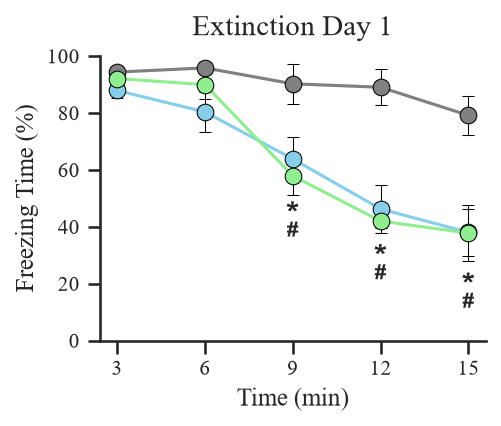

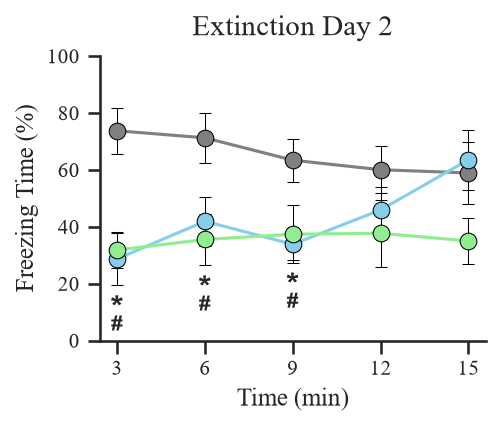

In [8]:
# 関数を使ってグラフを描画 (seaborn)

figEx1, axEx1 = plot_save(
    dataEx1_per3,
    title="Extinction Day 1",
    group_order=["SED", "LIE", "MOE"],
    save_path=r"C:\Users\sryoh\Documents\Python_MSSE_analysis\Results\Plots\Extinction_day1_per3_seaborn.png",
    show_legend=False,
    figsize=(3.5, 3),
    method="seaborn",
)

# 有意マーカーを描画
axEx1.text(9, 38, "*", ha="center", va="bottom", fontsize=16, fontweight="bold")
axEx1.text(12, 23, "*", ha="center", va="bottom", fontsize=16, fontweight="bold")
axEx1.text(15, 13, "*", ha="center", va="bottom", fontsize=16, fontweight="bold") # noqa: F821
axEx1.text(9, 35, "#", ha="center", va="bottom", fontsize=10, fontweight="bold")
axEx1.text(12, 20, "#", ha="center", va="bottom", fontsize=10, fontweight="bold")
axEx1.text(15, 10, "#", ha="center", va="bottom", fontsize=10, fontweight="bold") # noqa: F821

figEx1.tight_layout()

figEx1.savefig(
    r"C:\Users\sryoh\Documents\Python_MSSE_analysis\Results\Plots\Extinction_day1_per3_seaborn_sig.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

figEx2, axEx2 = plot_save(
    dataEx2_per3,
    title="Extinction Day 2",
    group_order=["SED", "LIE", "MOE"],
    save_path=r"C:\Users\sryoh\Documents\Python_MSSE_analysis\Results\Plots\Extinction_day2_per3_seaborn.png",
    show_legend=False,
    figsize=(3.5,3),
    method="seaborn",
)

# 有意マーカーを描画
axEx2.text(3, 5, "*", ha="center", va="bottom", fontsize=16, fontweight="bold")
axEx2.text(6, 12, "*", ha="center", va="bottom", fontsize=16, fontweight="bold")
axEx2.text(9, 13, "*", ha="center", va="bottom", fontsize=16, fontweight="bold") # noqa: F821
axEx2.text(3, 2, "#", ha="center", va="bottom", fontsize=10, fontweight="bold")
axEx2.text(6, 9, "#", ha="center", va="bottom", fontsize=10, fontweight="bold")
axEx2.text(9, 10, "#", ha="center", va="bottom", fontsize=10, fontweight="bold") # noqa: F821

figEx2.tight_layout()

figEx2.savefig(
    r"C:\Users\sryoh\Documents\Python_MSSE_analysis\Results\Plots\Extinction_day2_per3_seaborn_sig.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()